# Benchmark 02: All-Atom vs. $C_\alpha$-Only Solvent Accessible Surface Area (SASA)

## 1. Background & Context
In **Module 1 (Structure Graph Engine)**, relative Solvent Accessible Surface Area ($\text{rSASA}$) serves as a core spatial node feature ($\text{rSASA} \in [0, 1]$), capturing steric occlusion and solvent exposure for each residue.

To calculate SASA using FreeSASA's C-bindings (`freesasa.calcCoord`), we evaluated two architectural strategies operating on `MMCIF2Dict` extracted coordinates:

* **Option A (All-Atom SASA):** Extract all heavy atoms ($M \approx 10,000$), calculate per-atom VdW surface accessibility via element-specific radii, and aggregate atomic SASA values to the residue level.
* **Option B ($C_\alpha$-Only SASA):** Extract only backbone $C_\alpha$ atoms ($N \approx 1,290$) and calculate coarse-grained surface accessibility using a uniform spherical radius ($R_{C_\alpha} = 3.5\text{ \AA}$).

## 2. Hypothesis
While Option B reduces memory and array size by coarse-graining coordinates to $C_\alpha$ atoms, Option A will provide superior physical accuracy—particularly for bulky hydrophobic (Trp, Phe) or long charged (Lys, Arg) sidechains where the $C_\alpha$ backbone position does not reflect sidechain exposure.

## 3. Experimental Setup & Results
Using benchmark Cryo-EM structure `8r3y.cif`, we measured total processing latency (extraction + FreeSASA computation), peak memory allocation via `tracemalloc`, and statistical correlation ($r$ and $\rho$) between both feature vectors across 1,290 aligned residues.

### Benchmark Metrics
| Metric | Option A (All-Atom) | Option B ($C_\alpha$-Only) | Delta / Impact |
| :--- | :---: | :---: | :---: |
| **Execution Latency** | **9,166.62 ms** | 4,013.37 ms | +5.15 s (all heavy atoms) |
| **Peak Memory RAM** | **25.79 MB** | 17.99 MB | +7.80 MB |
| **Pearson Correlation ($r$)** | — | — | **0.8002** |
| **Spearman Correlation ($\rho$)** | — | — | **0.8109** |

---

## 4. Key Findings & Biological Analysis
1. **Uncaptured Variance (36%):** A Pearson correlation of $r = 0.8002$ implies that $C_\alpha$-only coarse-graining accounts for only $r^2 = 64.0\%$ of the true surface accessibility variance. The remaining **35.98% uncaptured variance** introduces systematic errors for buried backbones with solvent-exposed sidechains.
2. **Rank Misalignment ($\rho = 0.8109$):** The Spearman rank correlation confirms that $C_\alpha$-only SASA alters the relative exposure ranking of residues across the protein interface, risking misclassification of buried vs. exposed functional sites.
3. **Acceptable Computational Overhead:** While Option A takes ~9.17 seconds on the full multi-chain complex `8r3y`, it operates completely in-memory via `MMCIF2Dict` arrays and `freesasa.calcCoord`, avoiding file-system I/O and BioPython object hierarchy overhead.

---

## 5. Architectural Decision
**Verdict: Adopt Option A (All-Atom SASA Aggregated Per Residue).**

We will refactor `StructureParser` to extract all heavy atoms via `MMCIF2Dict`, compute exact atomic SASA via `freesasa.calcCoord`, aggregate atomic areas per residue key `(asym_id, seq_id)`, and normalize by empirical MaxASA values (Tien et al., 2013) to populate the final 26-dimensional node feature tensor ($X \in \mathbb{R}^{N \times 26}$).

In [2]:
import time
import tracemalloc
from pathlib import Path
import freesasa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from scipy.stats import pearsonr, spearmanr

In [9]:
data_dir = Path("../data")
data_dir.mkdir(parents=True, exist_ok=True)

input_dir = data_dir / "input"
input_dir.mkdir(parents=True, exist_ok=True)

In [10]:
# MaxASA empirical maximum values (Tien et al., 2013) in Å²
MAX_ASA = {
    "ALA": 129.0,
    "ARG": 274.0,
    "ASN": 195.0,
    "ASP": 193.0,
    "CYS": 167.0,
    "GLN": 225.0,
    "GLU": 223.0,
    "GLY": 104.0,
    "HIS": 224.0,
    "ILE": 197.0,
    "LEU": 201.0,
    "LYS": 236.0,
    "MET": 224.0,
    "PHE": 240.0,
    "PRO": 159.0,
    "SER": 155.0,
    "THR": 172.0,
    "TRP": 285.0,
    "TYR": 263.0,
    "VAL": 174.0,
}

VDW_RADII = {"C": 1.70, "N": 1.55, "O": 1.52, "S": 1.80, "P": 1.80}
 

In [11]:
def extract_atoms_from_mmcif(cif_path: Path, ca_only: bool = False):
    """Extracts atomic coordinates, residue names, and chain keys directly

    from MMCIF2Dict without BioPython structure objects.
    """
    mmcif_dict = MMCIF2Dict(str(cif_path))

    x = np.array(mmcif_dict["_atom_site.Cartn_x"], dtype=np.float64)
    y = np.array(mmcif_dict["_atom_site.Cartn_y"], dtype=np.float64)
    z = np.array(mmcif_dict["_atom_site.Cartn_z"], dtype=np.float64)

    atom_ids = mmcif_dict["_atom_site.label_atom_id"]
    comp_ids = mmcif_dict["_atom_site.label_comp_id"]
    asym_ids = mmcif_dict["_atom_site.label_asym_id"]
    seq_ids = mmcif_dict["_atom_site.label_seq_id"]

    coords_list, keys_list, atom_names_list, res_names_list = [], [], [], []

    for i in range(len(x)):
        # Skip hydrogen or non-standard null seq_ids
        if seq_ids[i] == "." or comp_ids[i] not in MAX_ASA:
            continue

        atom_name = atom_ids[i].strip()
        if ca_only and atom_name != "CA":
            continue

        coords_list.append([x[i], y[i], z[i]])
        keys_list.append((asym_ids[i], seq_ids[i]))
        atom_names_list.append(atom_name)
        res_names_list.append(comp_ids[i])

    return (
        np.array(coords_list, dtype=np.float64),
        keys_list,
        atom_names_list,
        res_names_list,
    )

In [12]:
def compute_rsasa_via_calpcoord(
    coords_np: np.ndarray,
    keys: list,
    atom_names: list,
    res_names: list,
    ca_only_mode: bool = False,
) -> dict:
    """Runs FreeSASA directly on NumPy coordinate arrays and computes rSASA."""
    if len(coords_np) == 0:
        return {}

    flat_coords = coords_np.flatten().tolist()

    if ca_only_mode:
        # Coarse-grained C-alpha sphere approximation (e.g. R = 3.5 Å)
        radii = [3.5] * len(coords_np)
    else:
        # Element-specific Van der Waals radii
        radii = [VDW_RADII.get(name[0].upper(), 1.70) for name in atom_names]

    # Direct C-binding calculation (in-memory)
    result = freesasa.calcCoord(flat_coords, radii)

    # Aggregate atomic SASA to residue level
    raw_sasa_map = {}
    res_type_map = {}

    for i, key in enumerate(keys):
        atom_area = result.atomArea(i)
        raw_sasa_map[key] = raw_sasa_map.get(key, 0.0) + atom_area
        res_type_map[key] = res_names[i]

    # Normalize by MaxASA -> rSASA
    rsasa_map = {}
    for key, raw_sasa in raw_sasa_map.items():
        aa_type = res_type_map[key]
        max_asa = MAX_ASA.get(aa_type, 200.0)
        rsasa_map[key] = min(1.0, raw_sasa / max_asa)

    return rsasa_map

In [13]:
CIF_PATH = Path(input_dir / "8r3y.cif") 

# --- Option A: All-Atom SASA (MMCIF2Dict -> calcCoord) ---
tracemalloc.start()
t0 = time.perf_counter()

coords_all, keys_all, names_all, res_all = extract_atoms_from_mmcif(
    CIF_PATH, ca_only=False
)
rsasa_A = compute_rsasa_via_calpcoord(
    coords_all, keys_all, names_all, res_all, ca_only_mode=False
)

t_option_A = (time.perf_counter() - t0) * 1000
_, peak_mem_A = tracemalloc.get_traced_memory()
tracemalloc.stop()

# --- Option B: C-alpha Only SASA (MMCIF2Dict -> calcCoord) ---
tracemalloc.start()
t0 = time.perf_counter()

coords_ca, keys_ca, names_ca, res_ca = extract_atoms_from_mmcif(
    CIF_PATH, ca_only=True
)
rsasa_B = compute_rsasa_via_calpcoord(
    coords_ca, keys_ca, names_ca, res_ca, ca_only_mode=True
)

t_option_B = (time.perf_counter() - t0) * 1000
_, peak_mem_B = tracemalloc.get_traced_memory()
tracemalloc.stop()

# --- Align Shared Residue Keys ---
common_keys = [k for k in rsasa_A if k in rsasa_B]
vec_A = np.array([rsasa_A[k] for k in common_keys])
vec_B = np.array([rsasa_B[k] for k in common_keys])

r_p, _ = pearsonr(vec_A, vec_B)
r_s, _ = spearmanr(vec_A, vec_B)

print(
    f"Option A (All-Atom):  {t_option_A:.2f} ms | Peak RAM:"
    f" {peak_mem_A / 1024 / 1024:.2f} MB"
)
print(
    f"Option B (C-alpha):   {t_option_B:.2f} ms | Peak RAM:"
    f" {peak_mem_B / 1024 / 1024:.2f} MB"
)
print(f"Pearson Correlation (r):  {r_p:.4f}")
print(f"Spearman Correlation (ρ): {r_s:.4f}")

Option A (All-Atom):  9166.62 ms | Peak RAM: 25.79 MB
Option B (C-alpha):   4013.37 ms | Peak RAM: 17.99 MB
Pearson Correlation (r):  0.8002
Spearman Correlation (ρ): 0.8109


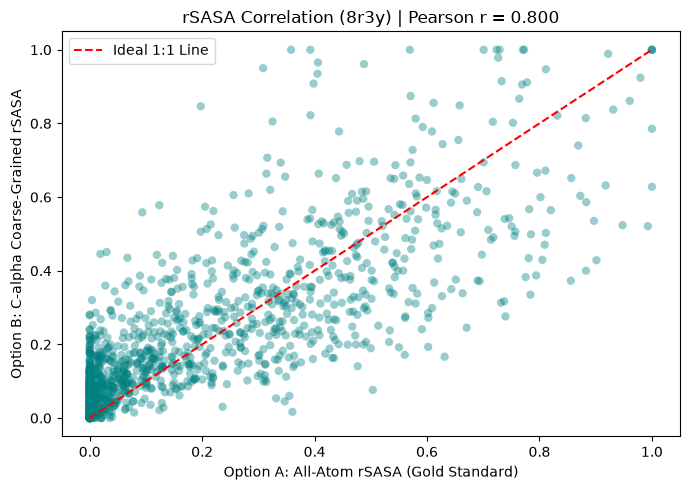

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(vec_A, vec_B, alpha=0.4, color="teal", edgecolors="none")
plt.plot([0, 1], [0, 1], "r--", label="Ideal 1:1 Line")
plt.xlabel("Option A: All-Atom rSASA (Gold Standard)")
plt.ylabel("Option B: C-alpha Coarse-Grained rSASA")
plt.title(f"rSASA Correlation (8r3y) | Pearson r = {r_p:.3f}")
plt.legend()
plt.tight_layout()
plt.show()